In [ ]:
# Data collection command:
# `python comet_download.py --project=eliminate-step-size --n_threads=8`

In [2]:
from collections import defaultdict
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from phd.feature_search.analysis.analysis_utils import *
from phd.feature_search.analysis.plotting import plot_learning_curves, plot_param_sensitivity

sns.set_theme('notebook', 'white')
%matplotlib inline

In [3]:
save_path = 'figures/'
config_data_path = 'data/eliminate-step-size_params.csv'
run_data_path = 'data/eliminate-step-size_metrics.csv'

config_dfs, run_dfs = load_experiment_data(config_data_path, run_data_path)
# del config_dfs[np.nan], run_dfs[np.nan]

{k: len(v) for k, v in config_dfs.items()}

{'ideal_features': 42, 'cbp_utility': 84, 'mean_initial_step_size': 26}

In [4]:
print("_____Best Hyperparameter Configurations_____")

sweep_split_vars = {
    'cbp_utility': ['feature_recycling|use_signed_utility'],
    'mean_initial_step_size': ['feature_recycling|initial_step_size_method'],
}

best_config_dfs, best_run_dfs, best_var_vals = get_best_ablation_values(
    config_dfs, run_dfs, sweep_split_vars=sweep_split_vars)

_____Best Hyperparameter Configurations_____

=== ideal_features ===

Configuration: (no split vars) | # runs: 1
  Best optimizer|meta_learning_rate=2**-6
  Best optimizer|learning_rate=2**-18


=== cbp_utility ===

Configuration: feature_recycling|use_signed_utility=False | # runs: 1
  Best optimizer|meta_learning_rate=2**-5
  Best optimizer|learning_rate=2**-14

Configuration: feature_recycling|use_signed_utility=True | # runs: 1
  Best optimizer|meta_learning_rate=2**-3
  Best optimizer|learning_rate=2**-18


=== mean_initial_step_size ===

Configuration: feature_recycling|initial_step_size_method=constant | # runs: 1
  Best optimizer|learning_rate=2**-15

Configuration: feature_recycling|initial_step_size_method=mean | # runs: 1
  Best optimizer|learning_rate=2**-15



In [9]:
best_run_dfs['ideal_features']
max_step = best_run_dfs['ideal_features']['step'].max()
threshold_step = int(max_step * 0.95)
ideal_loss = best_run_dfs['ideal_features']['loss'][
    best_run_dfs['ideal_features']['step'] >= threshold_step
].mean()

## Learning Curves

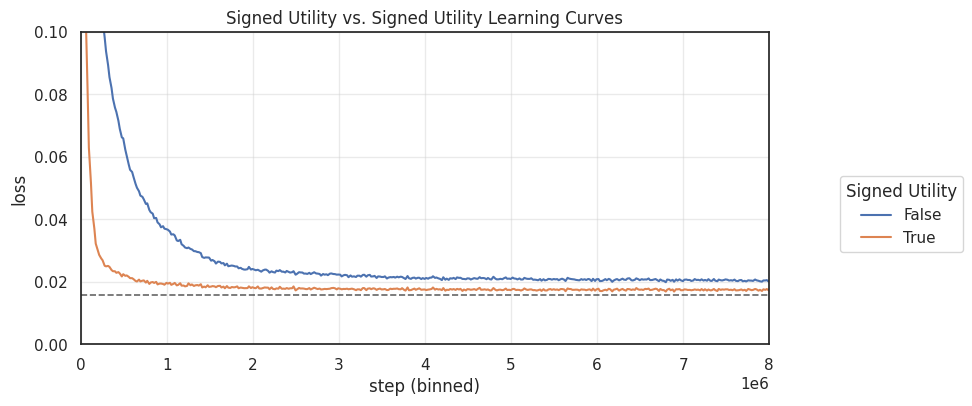

In [ ]:
plot_learning_curves(
    run_df = best_run_dfs['cbp_utility'],
    config_df = best_config_dfs['cbp_utility'],
    n_bins = 1000,
    figsize = (8, 4),
    max_cols = 1,
    hue_col = 'feature_recycling|use_signed_utility',
    legend_title = 'Signed Utility',
)
plt.ylim(0.0, 0.1)
plt.axhline(ideal_loss, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
plt.title('Signed Utility vs. Signed Utility Learning Curves')
plt.show()

## Hyperparameter Sensitivity

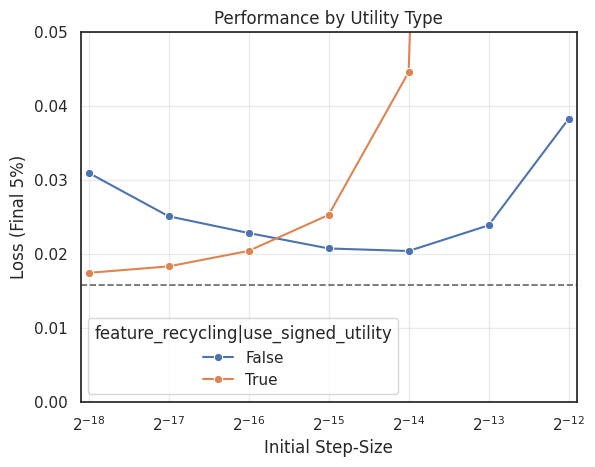

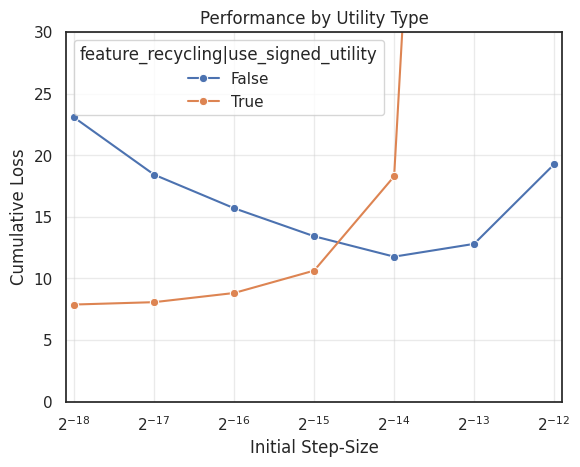

In [20]:
cbp_utility_run_df, cbp_utility_config_df = select_experiment_runs(
    run_df = run_dfs['cbp_utility'],
    config_df = config_dfs['cbp_utility'],
    chosen_values = {
        'feature_recycling|use_signed_utility': False,
        'optimizer|meta_learning_rate': best_var_vals['cbp_utility&feature_recycling|use_signed_utility=False']['optimizer|meta_learning_rate'],
    },
)

signed_utility_run_df, signed_utility_config_df = select_experiment_runs(
    run_df = run_dfs['cbp_utility'],
    config_df = config_dfs['cbp_utility'],
    chosen_values = {
        'feature_recycling|use_signed_utility': True,
        'optimizer|meta_learning_rate': best_var_vals['cbp_utility&feature_recycling|use_signed_utility=True']['optimizer|meta_learning_rate'],
    },
)

plot_run_df = pd.concat([cbp_utility_run_df, signed_utility_run_df])
plot_config_df = pd.concat([cbp_utility_config_df, signed_utility_config_df])

plot_param_sensitivity(
    run_df = plot_run_df,
    config_df = plot_config_df,
    x_col = 'optimizer|learning_rate',
    title = 'Performance by Utility Type',
    x_label = 'Initial Step-Size',
    y_label = 'Loss',
    hue_col = 'feature_recycling|use_signed_utility',
    metric_type = 'final_avg',
    pow_2_x_axis = True,
)
plt.axhline(ideal_loss, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
plt.ylim(0.0, 0.05)
plt.show()

plot_param_sensitivity(
    run_df = plot_run_df,
    config_df = plot_config_df,
    x_col = 'optimizer|learning_rate',
    title = 'Performance by Utility Type',
    x_label = 'Initial Step-Size',
    y_label = 'Loss',
    hue_col = 'feature_recycling|use_signed_utility',
    metric_type = 'cumulative',
    pow_2_x_axis = True,
)
plt.ylim(0.0, 30)
plt.show()
    

### With Baseline

/tmp/ipykernel_7032/1493863580.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_config_df.loc[:, 'Method'] = plot_config_df['model.use_perfect_features'].apply(


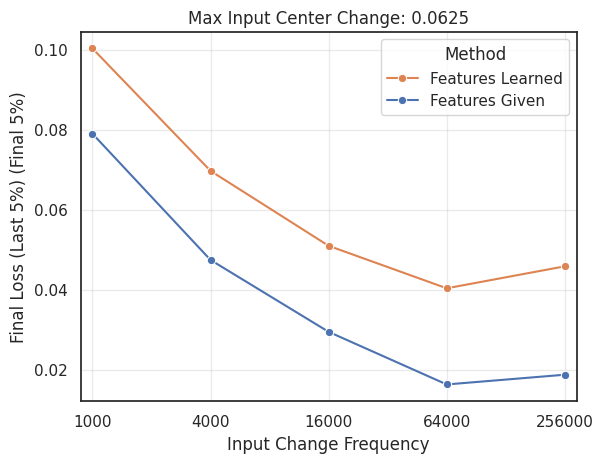

/tmp/ipykernel_7032/1493863580.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_config_df.loc[:, 'Method'] = plot_config_df['model.use_perfect_features'].apply(


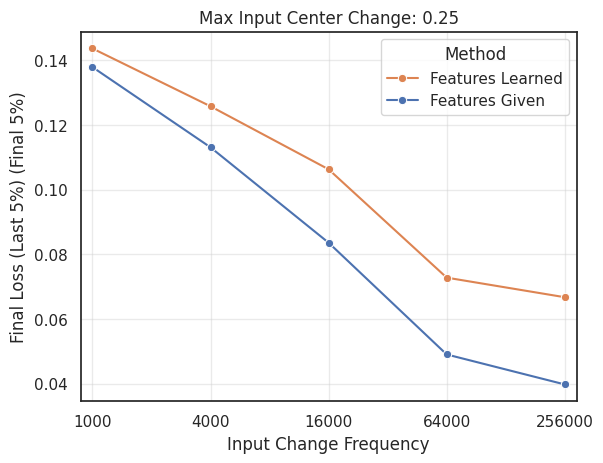

/tmp/ipykernel_7032/1493863580.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_config_df.loc[:, 'Method'] = plot_config_df['model.use_perfect_features'].apply(


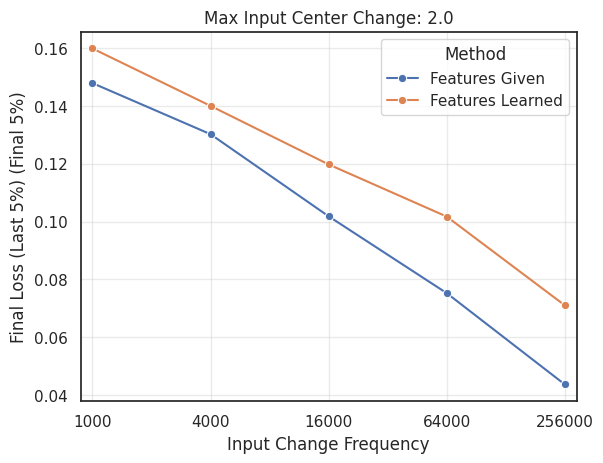

In [20]:
combined_run_df = pd.concat(run_dfs.values())
combined_config_df = pd.concat(config_dfs.values())

for max_input_center_change in [0.0625, 0.25, 2.0]:
    plot_run_df, plot_config_df = select_experiment_runs(
        run_df = combined_run_df,
        config_df = combined_config_df,
        chosen_values = {
            'task|max_input_center_change': max_input_center_change,
        },
    )

    plot_config_df.loc[:, 'Method'] = plot_config_df['model.use_perfect_features'].apply(
        lambda x: 'Features Given' if x == True else 'Features Learned'
    )

    plot_param_sensitivity(
        run_df = plot_run_df,
        config_df = plot_config_df,
        x_col = 'task|input_change_freq',
        title = 'Performance on Core Transient Task',
        x_label = 'Input Change Frequency',
        y_label = 'Final Loss (Last 5%)',
        hue_col = 'Method',
        metric_type = 'final_avg',
        pow_2_legend = True,
    )
    plt.title(f'Max Input Center Change: {max_input_center_change}')
    plt.show()

        

/tmp/ipykernel_1559/2339433291.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_config_df.loc[:, 'Method'] = plot_config_df['model.use_perfect_features'].apply(


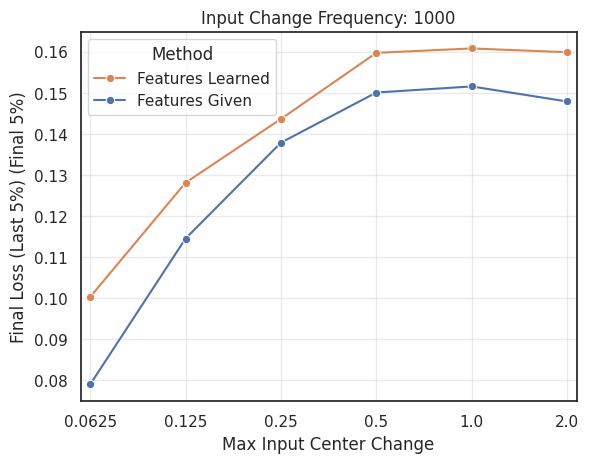

/tmp/ipykernel_1559/2339433291.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_config_df.loc[:, 'Method'] = plot_config_df['model.use_perfect_features'].apply(


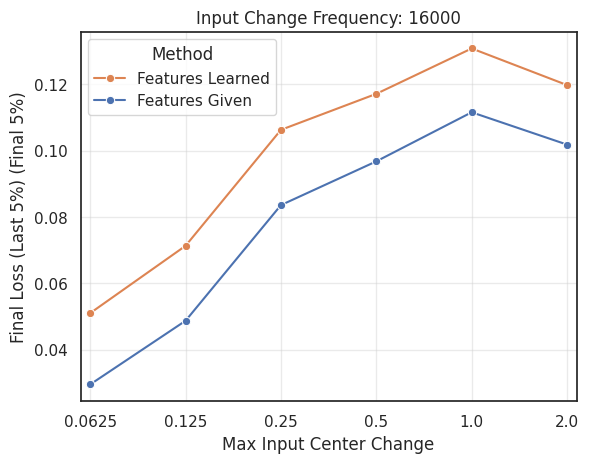

/tmp/ipykernel_1559/2339433291.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_config_df.loc[:, 'Method'] = plot_config_df['model.use_perfect_features'].apply(


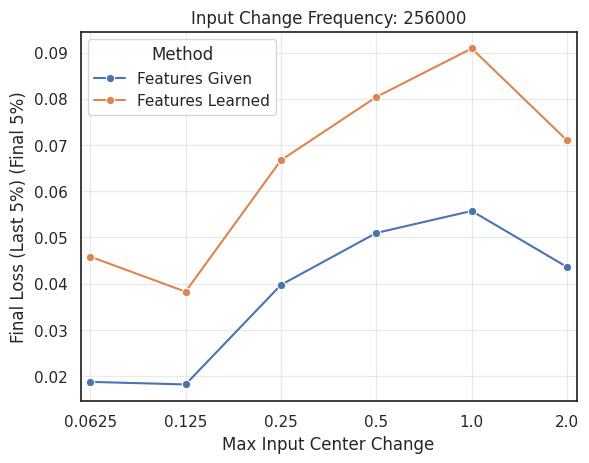

In [7]:
combined_run_df = pd.concat(run_dfs.values())
combined_config_df = pd.concat(config_dfs.values())

for change_freq in [1000, 16000, 256000]:
    plot_run_df, plot_config_df = select_experiment_runs(
        run_df = combined_run_df,
        config_df = combined_config_df,
        chosen_values = {
            'task|input_change_freq': change_freq,
        },
    )

    plot_config_df.loc[:, 'Method'] = plot_config_df['model.use_perfect_features'].apply(
        lambda x: 'Features Given' if x == True else 'Features Learned'
    )

    plot_param_sensitivity(
        run_df = plot_run_df,
        config_df = plot_config_df,
        x_col = 'task|max_input_center_change',
        title = 'Performance on Core Transient Task',
        x_label = 'Max Input Center Change',
        y_label = 'Final Loss (Last 5%)',
        hue_col = 'Method',
        metric_type = 'final_avg',
        pow_2_legend = True,
    )
    plt.title(f'Input Change Frequency: {change_freq}')
    plt.show()

        

## Normalized Loss Trends

In [14]:
# 1. Get avg loss over last 10% time steps for every single run
# 2. Get avg loss of each run over the feature given baseline
# 3. Plot those points in two scatter plots, one against the change frequency, and another against the max input center change (pairplot)

max_step = combined_run_df['step'].max()
last_10_percent_step = int(max_step * 0.9)
last_10_percent_run_df = combined_run_df[combined_run_df['step'] >= last_10_percent_step]

# Merge 'model.use_perfect_features', 'task|input_change_freq', 'task|max_input_center_change' into last_10_percent_run_df
last_10_percent_run_df = last_10_percent_run_df.merge(
    combined_config_df[['run_id', 'model.use_perfect_features', 'task|input_change_freq', 'task|max_input_center_change', 'seed']],
    on = 'run_id',
)
# Replace model.use_perfect_features nan values with False
last_10_percent_run_df.loc[:, 'model.use_perfect_features'] = last_10_percent_run_df['model.use_perfect_features'].fillna(False)

mean_loss_df = last_10_percent_run_df.groupby('run_id')[['loss', 'model.use_perfect_features', 'task|input_change_freq', 'task|max_input_center_change', 'seed']].mean()

# Now break into groups where everything is the same except for model.use_perfect_features, and make a new df with half the entries,
# with a normalized loss that is the without perfect features loss divided by the with perfect features loss
# The original code attempts to normalize loss for runs with/without perfect features,
# but can fail (KeyError) if group doesn't contain both True and False, or tries to
# assign [False, True] naively. We'll rewrite robustly:

def compute_normalized_loss(group):
    # Require exactly two entries: one for True, one for False
    if set(group['model.use_perfect_features']) == {True, False} and len(group) == 2:
        loss_with = group.loc[group['model.use_perfect_features'] == True, 'loss'].values[0]
        loss_without = group.loc[group['model.use_perfect_features'] == False, 'loss'].values[0]
        return pd.Series({
            'normalized_loss': loss_without / loss_with,
            'loss_with_features': loss_with,
            'loss_without_features': loss_without,
            'task|input_change_freq': group['task|input_change_freq'].iloc[0],
            'task|max_input_center_change': group['task|max_input_center_change'].iloc[0],
            'seed': group['seed'].iloc[0]
        })
    else:
        return None  # Not enough data for comparison

# Filter for only groups where both True and False are present
final_loss_df = (
    mean_loss_df
    .reset_index()
    .groupby(['task|input_change_freq', 'task|max_input_center_change', 'seed'])
    .apply(compute_normalized_loss)
    .dropna()
    .reset_index(drop=True)
)

final_loss_df

/tmp/ipykernel_1559/558265318.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  last_10_percent_run_df.loc[:, 'model.use_perfect_features'] = last_10_percent_run_df['model.use_perfect_features'].fillna(False)
/tmp/ipykernel_1559/558265318.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_normalized_loss)


,normalized_loss,loss_with_features,loss_without_features,task|input_change_freq,task|max_input_center_change,seed
0,3.174474,0.013574,0.043089,5000000.0,2.0,101.0
1,2.701680,0.014823,0.040047,5000000.0,2.0,102.0
2,2.732155,0.010827,0.029580,5000000.0,2.0,103.0
3,5.799448,0.005319,0.030849,5000000.0,2.0,104.0
4,2.680762,0.011284,0.030250,5000000.0,2.0,105.0
5,3.029737,0.012247,0.037107,5000000.0,2.0,106.0
6,2.553411,0.013320,0.034010,5000000.0,2.0,107.0
7,2.652602,0.012975,0.034417,5000000.0,2.0,108.0
8,3.455038,0.012422,0.042920,5000000.0,2.0,109.0
9,2.910628,0.013383,0.038952,5000000.0,2.0,110.0


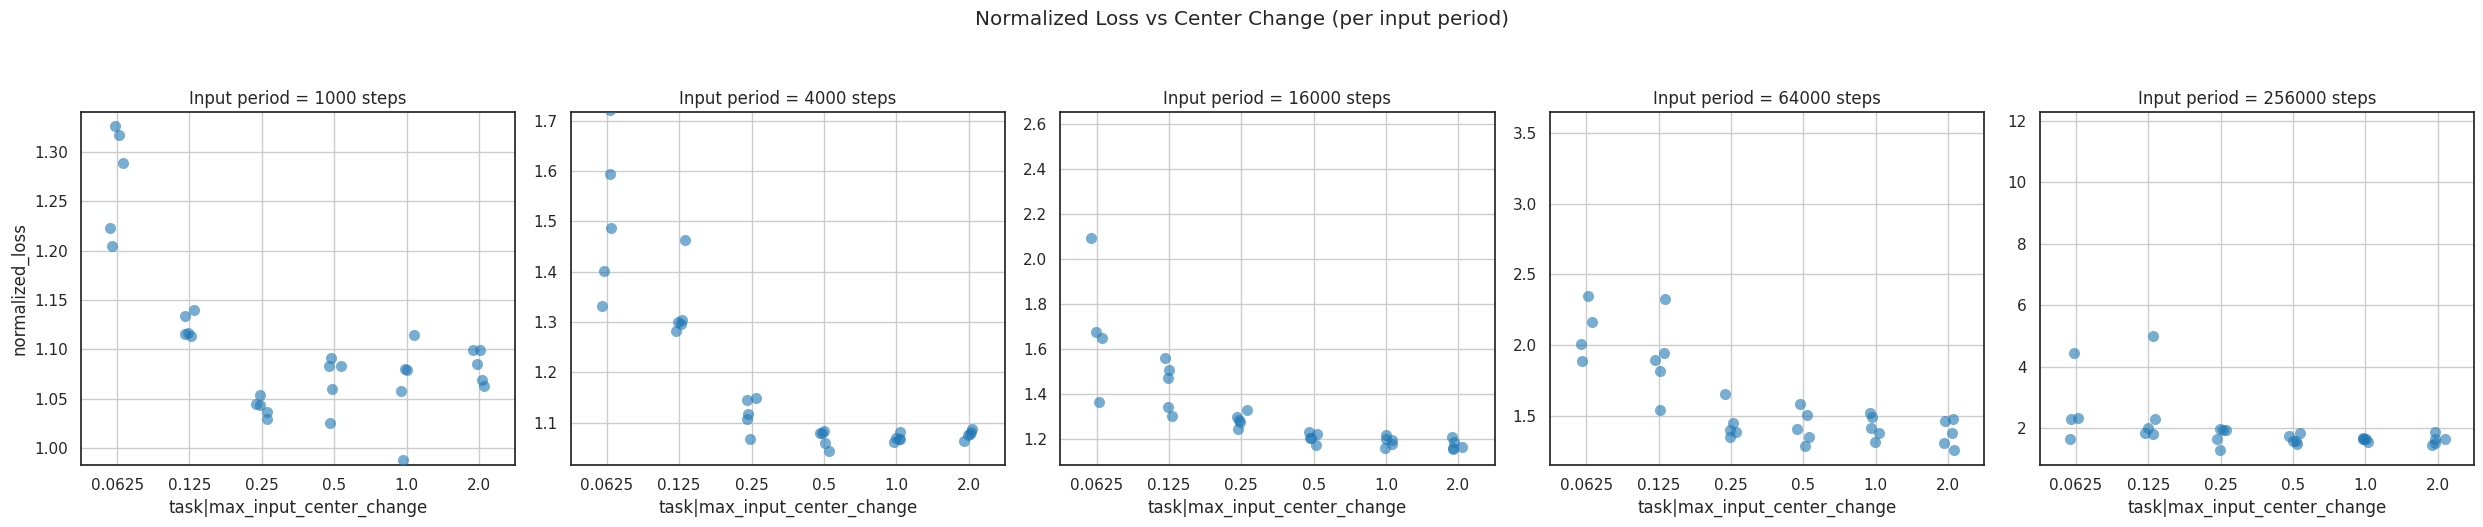

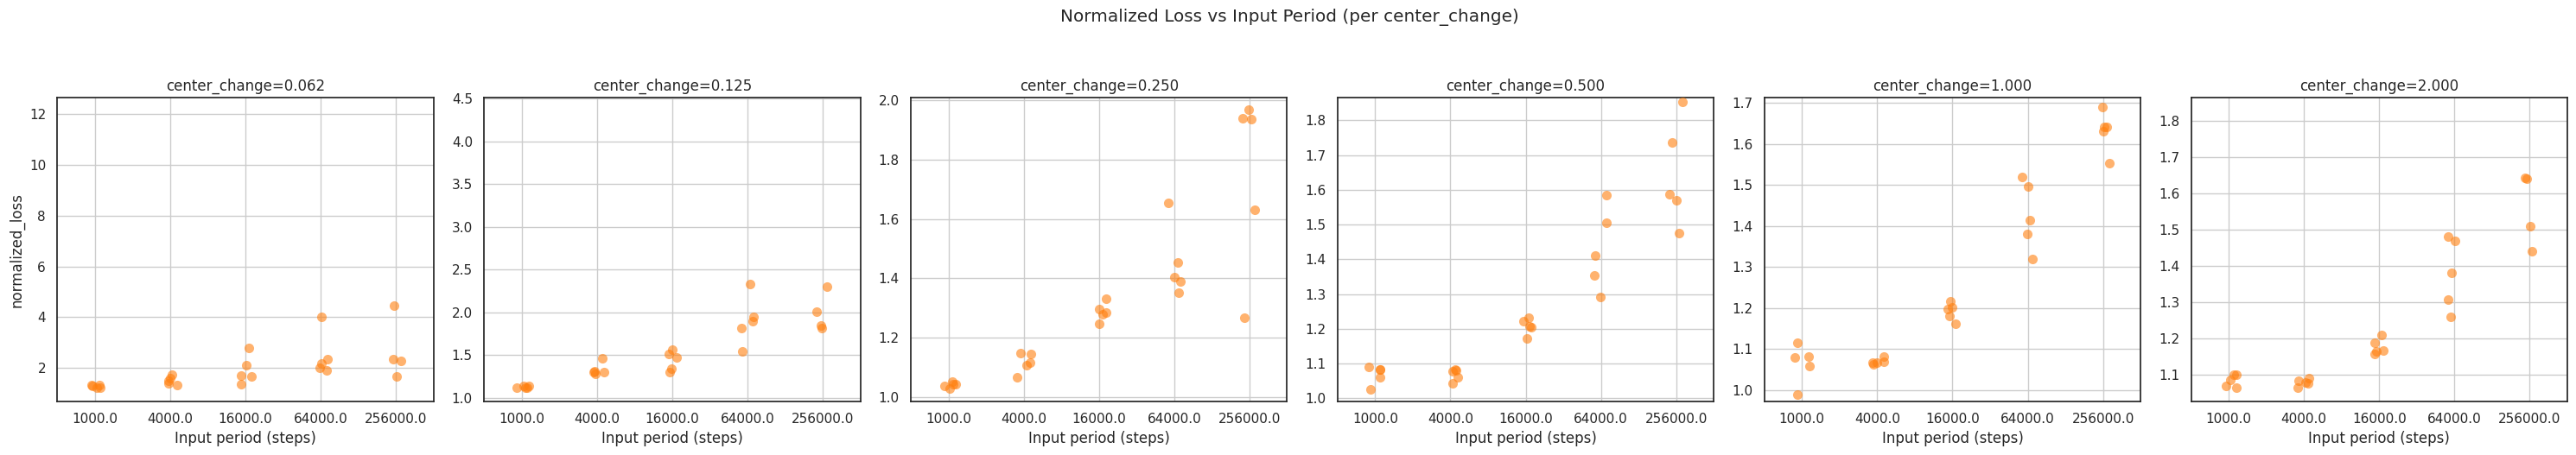

In [47]:
import seaborn as sns
import numpy as np

def get_non_outlier_limits(y, low_q=0.01, high_q=0.99, margin=0.05):
    # Return lower and upper y-limits excluding outliers, with small margin
    q_low, q_high = np.nanquantile(y, [low_q, high_q])
    delta = q_high - q_low
    lower = q_low - margin * delta
    upper = q_high + margin * delta
    return lower, upper

# First set: for each value of change_freq (period), plot normalized_loss vs center_change, horizontal subplots
unique_periods = np.sort(final_loss_df['task|input_change_freq'].unique())
n_periods = len(unique_periods)

fig1, axs1 = plt.subplots(1, n_periods, figsize=(5 * n_periods, 5), sharey=False)
if n_periods == 1:
    axs1 = [axs1]

for idx, period in enumerate(unique_periods):
    ax = axs1[idx]
    subdf = final_loss_df[final_loss_df['task|input_change_freq'] == period]
    # Remove outlier y for autoscale
    y = subdf['normalized_loss'].values
    if len(y) > 2:
        ylow, yhigh = get_non_outlier_limits(y)
    else:
        ylow, yhigh = np.nanmin(y), np.nanmax(y)
    sns.stripplot(
        data=subdf,
        x='task|max_input_center_change',
        y='normalized_loss',
        ax=ax,
        jitter=True,
        color='tab:blue',
        size=8,
        alpha=0.6
    )
    ax.set_ylim(ylow, yhigh)
    # Show the original period (input change interval) directly
    period_display = int(period) if period == int(period) else period
    title_str = f'Input period = {period_display} steps'
    ax.set_title(title_str)
    ax.set_xlabel('task|max_input_center_change')
    if idx == 0:
        ax.set_ylabel('normalized_loss')
    else:
        ax.set_ylabel("")
    ax.grid(True)
fig1.suptitle('Normalized Loss vs Center Change (per input period)', y=1.05)
plt.tight_layout()
plt.show()

# Second set: for each value of center_change, plot normalized_loss vs period, horizontal subplots
unique_center_changes = np.sort(final_loss_df['task|max_input_center_change'].unique())
n_center_changes = len(unique_center_changes)

fig2, axs2 = plt.subplots(1, n_center_changes, figsize=(5 * n_center_changes, 5), sharey=False)
if n_center_changes == 1:
    axs2 = [axs2]

for idx, cc in enumerate(unique_center_changes):
    ax = axs2[idx]
    subdf = final_loss_df[final_loss_df['task|max_input_center_change'] == cc]
    y = subdf['normalized_loss'].values
    if len(y) > 2:
        ylow, yhigh = get_non_outlier_limits(y)
    else:
        ylow, yhigh = np.nanmin(y), np.nanmax(y)
    # For plotting, use period directly (not steps_between_change = 1/freq)
    subdf = subdf.copy()
    subdf['input_period'] = subdf['task|input_change_freq']
    sns.stripplot(
        data=subdf,
        x='input_period',
        y='normalized_loss',
        ax=ax,
        jitter=True,
        color='tab:orange',
        size=8,
        alpha=0.6
    )
    ax.set_ylim(ylow, yhigh)
    ax.set_title(f'center_change={cc:.3f}')
    ax.set_xlabel('Input period (steps)')
    if idx == 0:
        ax.set_ylabel('normalized_loss')
    else:
        ax.set_ylabel("")
    ax.grid(True)
fig2.suptitle(r'Normalized Loss vs Input Period (per center_change)', y=1.05)
plt.tight_layout()
plt.show()


## SGD Baselines

In [ ]:
# 1. Plot best SGD, Split step-size SGD, and Autostep learning curves
# 2. Plot the same as above but for the features being given
# 3. Plot the ratio of the two for each method
# 4. Plot the long run with feature given and learned separately, then plot the ratio

# {'change_type': 150,
#  'change_type_given_features': 150,
#  'sgd': 100,
#  'sgd_split_step_size': 360,
#  'autostep_long_run_single_change': 80}

In [53]:
target_change_freq = 4000
target_center_change = 0.125

In [75]:
autostep_run_df = pd.concat([
    run_dfs['change_type'],
    run_dfs['change_type_given_features'],
])
autostep_config_df = pd.concat([
    config_dfs['change_type'],
    config_dfs['change_type_given_features'],
])

autostep_run_df, autostep_config_df = select_experiment_runs(
    run_df = autostep_run_df,
    config_df = autostep_config_df,
    chosen_values = {
        'task|input_change_freq': target_change_freq,
        'task|max_input_center_change': target_center_change,
    },
)

all_run_df = pd.concat([
    best_run_dfs['sgd'],
    best_run_dfs['sgd_split_step_size'],
    autostep_run_df,
])

all_config_df = pd.concat([
    best_config_dfs['sgd'],
    best_config_dfs['sgd_split_step_size'],
    autostep_config_df,
])

all_config_df['model|use_perfect_features'] = all_config_df['model|use_perfect_features'].fillna(False)

all_config_df['algorithm'] = all_config_df['sweep_name'].apply(lambda x: {
    'sgd': 'SGD',
    'sgd_split_step_size': 'Split Step-Size SGD',
    'change_type': 'Autostep',
    'change_type_given_features': 'Autostep',
}[x])

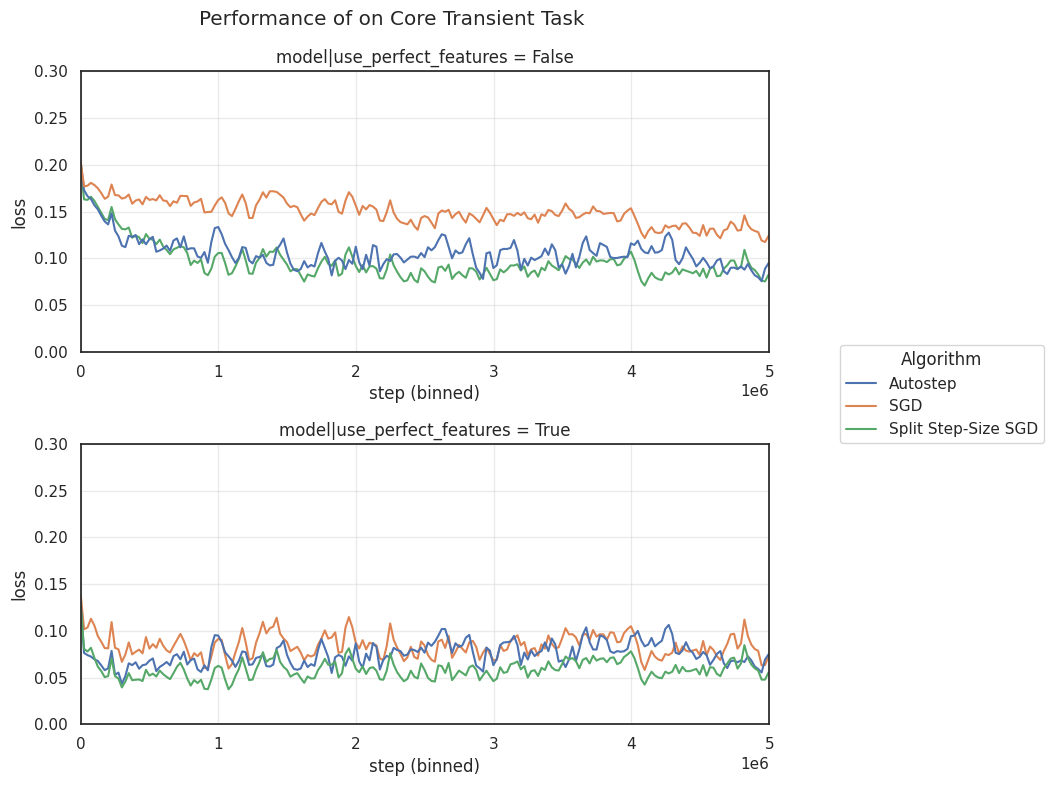

In [76]:
plot_learning_curves(
    run_df = all_run_df,
    config_df = all_config_df,
    n_bins = 200,
    figsize = (8, 8),
    max_cols = 1,
    hue_col = 'algorithm',
    subplot_col = 'model|use_perfect_features',
    legend_title = 'Algorithm',
    ylim = (0, 0.3),
)
plt.suptitle('Performance of on Core Transient Task')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2633/4003925004.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_normalized_loss)


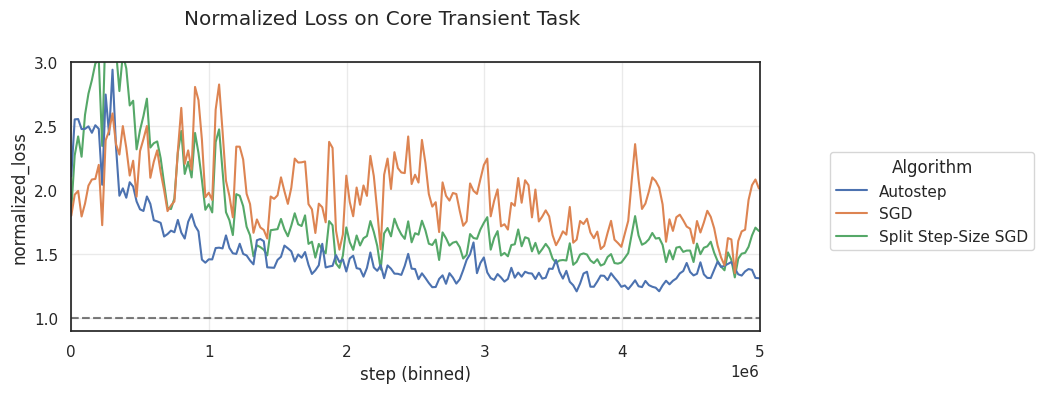

In [118]:
# First, merge to get the required columns into a single DataFrame
all_combined_df = all_run_df.merge(
    all_config_df[['run_id', 'model|use_perfect_features', 'seed', 'algorithm']],
    on = 'run_id',
)

# Keep only the columns we care about
cols_of_interest = [
    'run_id',
    'model|use_perfect_features',
    'seed',
    'step',
    'loss',
    'algorithm',
]
all_combined_df = all_combined_df[cols_of_interest]

group_cols = ['seed', 'step', 'algorithm']

def compute_normalized_loss(group):
    # Needs to be sorted by use_perfect_features for predictability
    group = group.sort_values('model|use_perfect_features')
    # Compute ratio only if both False/True exist
    if group['model|use_perfect_features'].nunique() == 2:
        no_pf_loss = group.loc[group['model|use_perfect_features'] == False, 'loss'].values[0]
        pf_loss = group.loc[group['model|use_perfect_features'] == True, 'loss'].values[0]
        norm_loss_true = no_pf_loss / pf_loss
        # For use_perfect_features==True, set to ratio; for False, set to 1.0 (since normalized wrt itself)
        norm_loss_vec = np.where(
            group['model|use_perfect_features'],
            1.0,
            norm_loss_true,
        )
        return pd.Series(norm_loss_vec, index=group.index)
    else:
        # Only one present, normalized loss is nan for both
        return pd.Series(np.nan, index=group.index)

all_combined_df['normalized_loss'] = (
    all_combined_df
    .groupby(group_cols, group_keys=False)
    .apply(compute_normalized_loss)
)

plot_df = all_combined_df[
    all_combined_df['model|use_perfect_features'] == False
]

plot_learning_curves(
    run_df = plot_df,
    n_bins = 200,
    figsize = (8, 4),
    max_cols = 1,
    y_col = 'normalized_loss',
    hue_col = 'algorithm',
    legend_title = 'Algorithm',
    ylim = (0.9, 3.0),
)
plt.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)  # Dotted, partially transparent line at y=0
plt.suptitle('Normalized Loss on Core Transient Task')
plt.tight_layout()
plt.show()

# Smaller gradients in input layer because of vanishing gradient from sigmoid?
# Look at gradient * step size, maybe it's actually very small?

## Single Change Experiment

In [38]:
# First, merge to get the required columns into a single DataFrame
plot_df = run_dfs['autostep_long_run_single_change'].merge(
    config_dfs['autostep_long_run_single_change'][['run_id', 'model|use_perfect_features', 'task|input_change_freq', 'seed']],
    on = 'run_id',
)

# Keep only the columns we care about
cols_of_interest = [
    'run_id',
    'model|use_perfect_features',
    'task|input_change_freq',
    'seed',
    'step',
    'loss',
]
plot_df = plot_df[cols_of_interest]

group_cols = ['seed', 'step', 'task|input_change_freq']


def compute_normalized_loss(group):
    # Require exactly two entries: one for True, one for False
    if set(group['model|use_perfect_features']) == {True, False} and len(group) == 2:
        loss_with = group.loc[group['model|use_perfect_features'] == True, 'loss'].values[0]
        loss_without = group.loc[group['model|use_perfect_features'] == False, 'loss'].values[0]
        return pd.Series({
            'run_id': group['run_id'].iloc[0],
            'step': group['step'].iloc[0],
            'normalized_loss': loss_without / loss_with,
            'loss_with_features': loss_with,
            'loss_without_features': loss_without,
            'task|input_change_freq': group['task|input_change_freq'].iloc[0],
            'seed': group['seed'].iloc[0]
        })
    else:
        return None  # Not enough data for comparison

normalized_loss_df = (
    plot_df
    .groupby(group_cols, group_keys=False)
    .apply(compute_normalized_loss)
    .dropna()
    .reset_index(drop=True)
)

/tmp/ipykernel_1559/1591185426.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_normalized_loss)


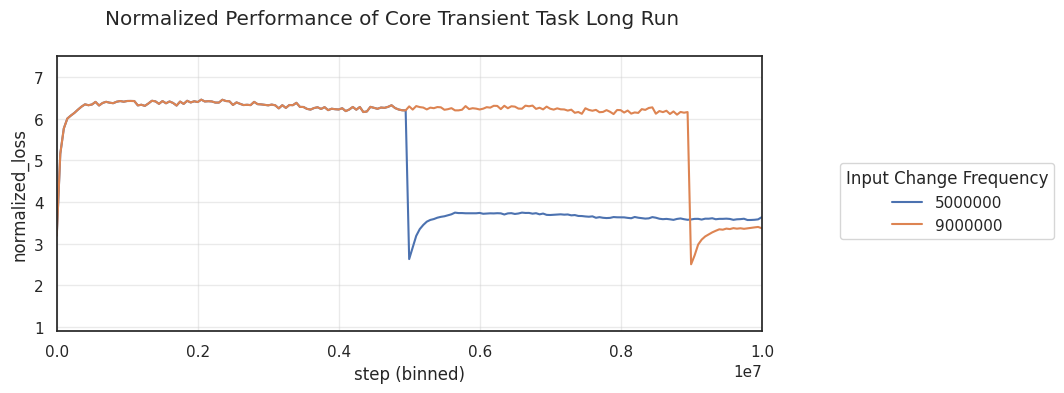

In [48]:
plot_learning_curves(
    run_df = normalized_loss_df,
    n_bins = 200,
    figsize = (8, 4),
    max_cols = 1,
    y_col = 'normalized_loss',
    hue_col = 'task|input_change_freq',
    legend_title = 'Input Change Frequency',
    ylim = (0.9, 7.5),
)
plt.suptitle('Normalized Performance of Core Transient Task Long Run')
plt.tight_layout()
plt.show()

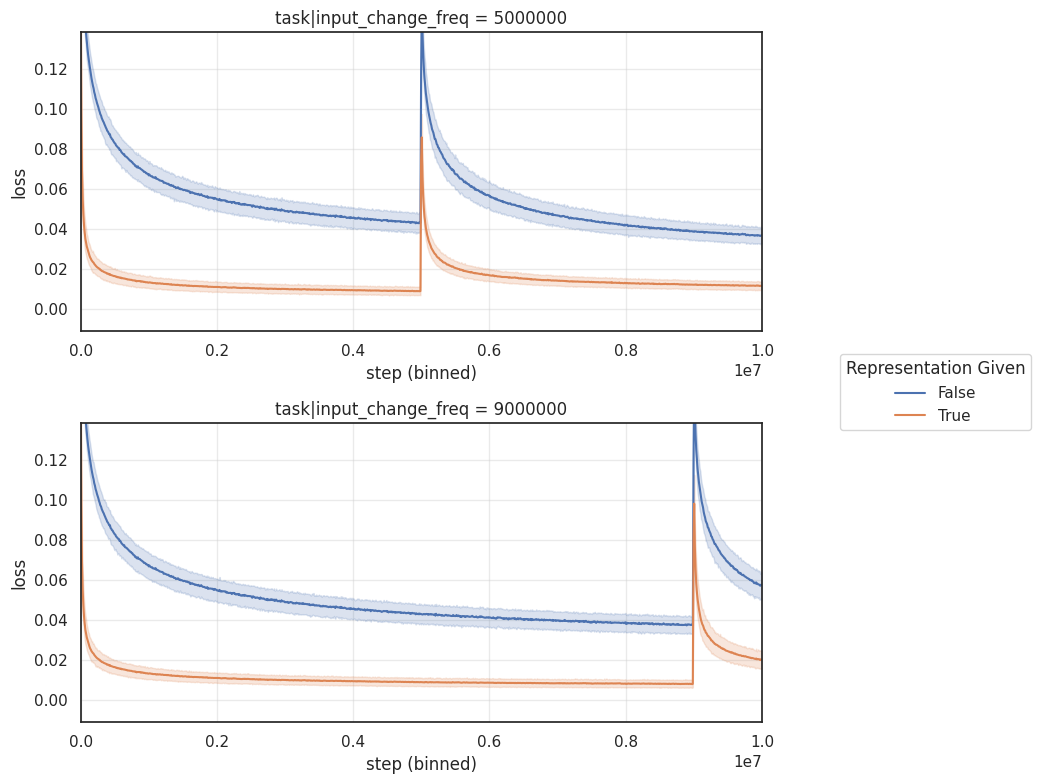

In [44]:
plot_learning_curves(
    run_df = run_dfs['autostep_long_run_single_change'],
    config_df = config_dfs['autostep_long_run_single_change'],
    n_bins = 1000,
    figsize = (8, 8),
    max_cols = 1,
    hue_col = 'model|use_perfect_features',
    subplot_col = 'task|input_change_freq',
    legend_title = 'Representation Given',
    show_ci = True,
)